In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Dell\Desktop\regression project\pmsm-temperature-prediction\data\raw\electric_motor_temperature.csv"
)

print(df.head())



   profile_id       u_q    coolant       u_d  motor_speed       i_d       i_q  \
0        17.0 -0.450682  18.805172 -0.350055     0.002866  0.004419  0.000328   
1        17.0 -0.325737  18.818571 -0.305803     0.000257  0.000606 -0.000785   
2        17.0 -0.440864  18.828770 -0.372503     0.002355  0.001290  0.000386   
3        17.0 -0.327026  18.835567 -0.316199     0.006105  0.000026  0.002046   
4        17.0 -0.471150  18.857033 -0.332272     0.003133 -0.064317  0.037184   

     ambient         pm  
0  19.850691  24.554214  
1  19.850672  24.538078  
2  19.850657  24.544693  
3  19.850647  24.554018  
4  19.850639  24.565397  


In [3]:
print(df.shape)

(1048575, 9)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   profile_id   1024486 non-null  float64
 1   u_q          1048575 non-null  float64
 2   coolant      1048575 non-null  float64
 3   u_d          1004481 non-null  float64
 4   motor_speed  1004481 non-null  float64
 5   i_d          1048575 non-null  float64
 6   i_q          1024486 non-null  float64
 7   ambient      1048575 non-null  float64
 8   pm           1048575 non-null  float64
dtypes: float64(9)
memory usage: 72.0 MB


In [5]:
df.isnull().sum()

profile_id     24089
u_q                0
coolant            0
u_d            44094
motor_speed    44094
i_d                0
i_q            24089
ambient            0
pm                 0
dtype: int64

In [6]:
df.describe()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
count,1.024486e+06,1.048575e+06,1.048575e+06,1.004481e+06,1.004481e+06,1.048575e+06,1.024486e+06,1.048575e+06,1.048575e+06
mean,3.549866e+01,5.333733e+01,3.232322e+01,-2.897310e+01,2.209562e+03,-7.092833e+01,4.328784e+01,2.423961e+01,5.691077e+01
std,2.506037e+01,4.336464e+01,2.027951e+01,6.222443e+01,1.874140e+03,6.660061e+01,9.158756e+01,1.940425e+00,2.001114e+01
min,2.000000e+00,-2.529093e+01,1.376190e+01,-1.315304e+02,-2.755491e+02,-2.780036e+02,-2.934268e+02,1.410069e+01,2.085696e+01
25%,1.400000e+01,1.209668e+01,1.860544e+01,-8.524918e+01,3.834424e+02,-1.192647e+02,1.096399e+00,2.309487e+01,3.900360e+01
50%,2.900000e+01,4.752466e+01,1.926167e+01,-7.620561e+00,1.999976e+03,-5.073550e+01,2.992296e+01,2.411081e+01,5.760014e+01
75%,5.700000e+01,8.757509e+01,4.179416e+01,8.298083e-01,3.749966e+03,-2.980322e+00,1.131802e+02,2.591768e+01,7.169332e+01
max,8.100000e+01,1.330313e+02,1.015985e+02,1.314698e+02,6.000015e+03,5.189670e-02,3.017079e+02,3.071420e+01,1.136066e+02


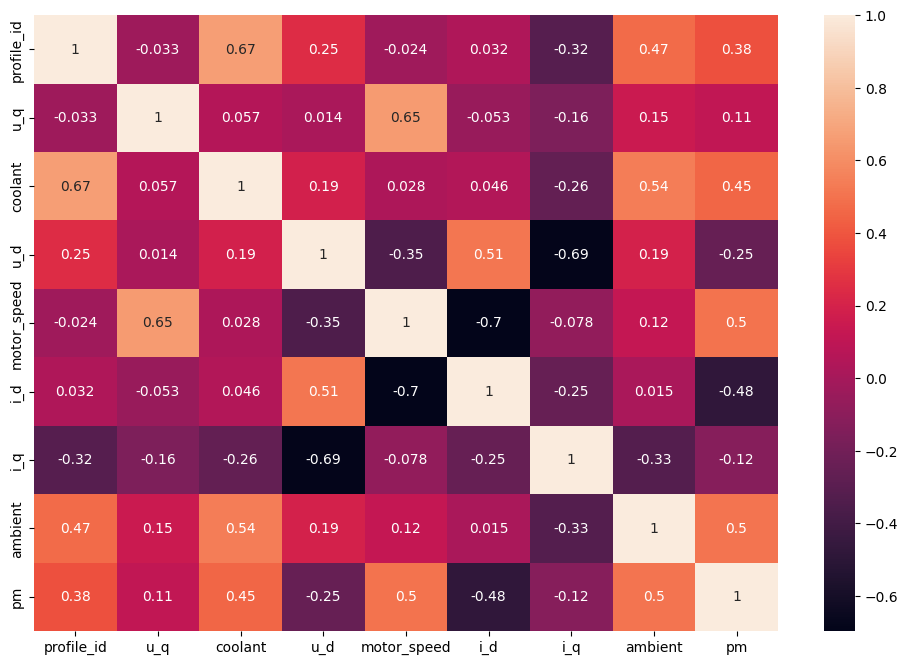

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

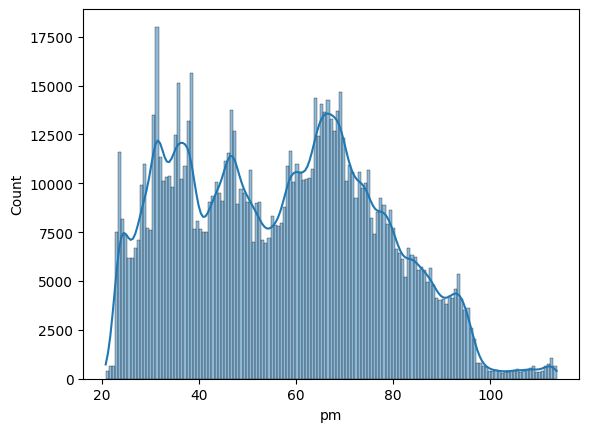

In [8]:
sns.histplot(df["pm"], kde=True)
plt.show()

<Axes: xlabel='motor_speed', ylabel='pm'>

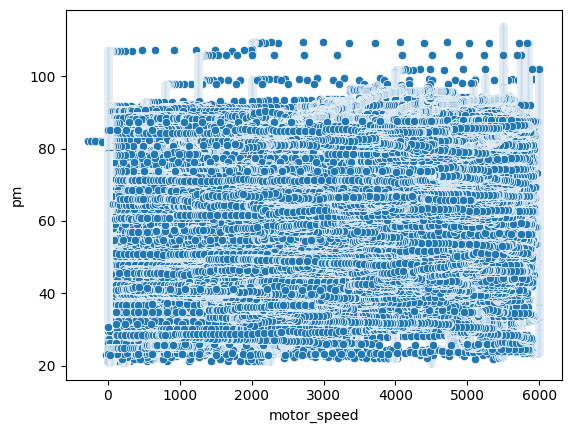

In [9]:
sns.scatterplot(x=df["motor_speed"], y=df["pm"])

In [10]:
from src.components.feature_engineering import FeatureEngineering
fe = FeatureEngineering()
df = fe.create_features(df)

In [11]:
df.head()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm,current_magnitude,voltage_magnitude,temp_difference
0,17.0,-0.450682,18.805172,-0.350055,0.002866,0.004419,0.000328,19.850691,24.554214,0.004431,0.570659,-1.045519
1,17.0,-0.325737,18.818571,-0.305803,0.000257,0.000606,-0.000785,19.850672,24.538078,0.000992,0.446789,-1.032101
2,17.0,-0.440864,18.828770,-0.372503,0.002355,0.001290,0.000386,19.850657,24.544693,0.001346,0.577165,-1.021887
3,17.0,-0.327026,18.835567,-0.316199,0.006105,0.000026,0.002046,19.850647,24.554018,0.002046,0.454893,-1.015079
4,17.0,-0.471150,18.857033,-0.332272,0.003133,-0.064317,0.037184,19.850639,24.565397,0.074292,0.576530,-0.993607


In [12]:
from src.components.data_preprocessing import DataPreprocessing
dp = DataPreprocessing()
X_train, X_test, y_train, y_test = dp.split_data(df)

In [13]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(838860, 11)
(209715, 11)
(838860,)
(209715,)


In [14]:
from src.components.model_trainer import ModelTrainer
trainer = ModelTrainer()

In [15]:
df = df.sample(
    100000,
    random_state=42
)

In [16]:
X_train, X_test, y_train, y_test = dp.split_data(df)

In [17]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(80000, 11)
(20000, 11)
(80000,)
(20000,)


In [18]:
X_train.isnull().sum()

profile_id           0
u_q                  0
coolant              0
u_d                  0
motor_speed          0
i_d                  0
i_q                  0
ambient              0
current_magnitude    0
voltage_magnitude    0
temp_difference      0
dtype: int64

In [19]:
X_train.isnull().sum().sum()

np.int64(0)

In [20]:
X_train = X_train.fillna(
    X_train.mean()
)

X_test = X_test.fillna(
    X_train.mean()
)

In [21]:
X_train.isnull().sum().sum()

np.int64(0)

In [22]:
results_df, trained_models = trainer.train_models(
    X_train,
    y_train,
    X_test,
    y_test
)


Training Linear Regression...
Linear Regression Completed
MAE: 9.2614
RMSE: 12.2845
R2 Score: 0.6260

Training Ridge Regression...
Ridge Regression Completed
MAE: 9.2614
RMSE: 12.2845
R2 Score: 0.6260

Training Random Forest...
Random Forest Completed
MAE: 1.0788
RMSE: 2.4351
R2 Score: 0.9853

Training XGBoost...
XGBoost Completed
MAE: 3.4205
RMSE: 4.8993
R2 Score: 0.9405

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2606
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 11
[LightGBM] [Info] Start training from score 56.920278
LightGBM Completed
MAE: 3.5920
RMSE: 5.0370
R2 Score: 0.9371

Training CatBoost...
CatBoost Completed
MAE: 3.2769
RMSE: 4.6612
R2 Score: 0.9462


In [23]:
results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,MAE,RMSE,R2 Score
Random Forest,1.0788,2.4351,0.9853
CatBoost,3.2769,4.6612,0.9462
XGBoost,3.4205,4.8993,0.9405
LightGBM,3.5920,5.0370,0.9371
Ridge Regression,9.2614,12.2845,0.6260
Linear Regression,9.2614,12.2845,0.6260


In [24]:
best_model_name = results_df.index[0]

print(best_model_name)

Random Forest


In [25]:
best_model = trained_models[
    "Random Forest"
]

In [26]:
importance = best_model.feature_importances_

In [27]:
features = X_train.columns

In [28]:
import pandas as pd

feature_importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": importance
})

In [29]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
2,coolant,0.353878
4,motor_speed,0.142491
7,ambient,0.115386
3,u_d,0.086353
5,i_d,0.067848
0,profile_id,0.066846
9,voltage_magnitude,0.049343
1,u_q,0.047894
6,i_q,0.028190
10,temp_difference,0.021691


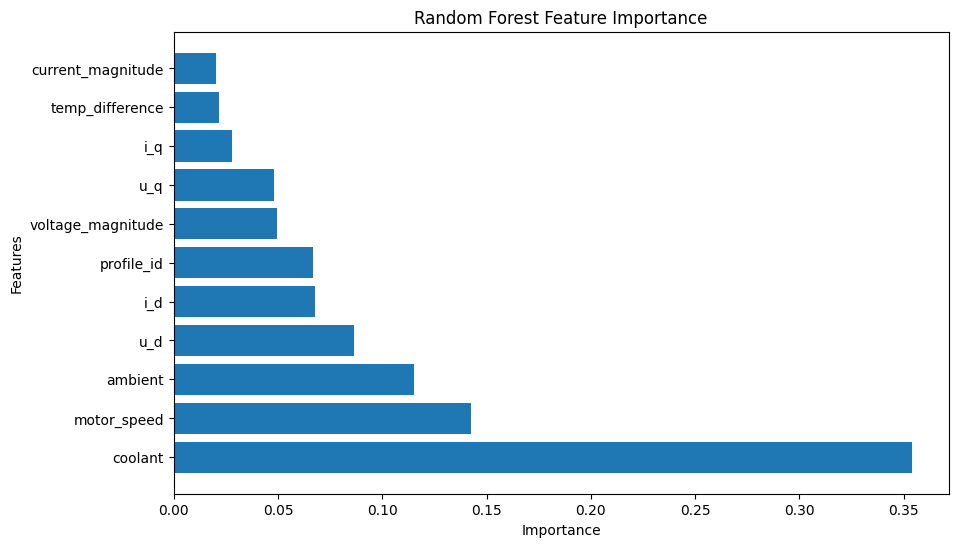

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

In [31]:
import os

os.makedirs("reports", exist_ok=True)

print("Reports folder created")

Reports folder created


In [32]:
feature_importance_df.to_csv(

    "reports/feature_importance.csv",

    index=False
)

print("Feature importance saved")

Feature importance saved


In [33]:
results_df.to_csv(

    "reports/model_results.csv",

    index=False
)

print("Model results saved")

Model results saved


In [34]:
import os

print(os.getcwd())

c:\Users\Dell\Desktop\regression project\pmsm-temperature-prediction\notebooks


In [35]:
import os
import joblib

os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    best_model,
    "models/best_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [36]:
import os

print(
    os.path.exists(
        "models/best_model.pkl"
    )
)

True


In [37]:
from src.pipeline.prediction_pipeline import PredictionPipeline

In [39]:
import os

print(os.getcwd())

c:\Users\Dell\Desktop\regression project\pmsm-temperature-prediction\notebooks


In [40]:
import os
import joblib

# Create models folder in project root
os.makedirs(
    "../models",
    exist_ok=True
)

# Save model
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [41]:
import os

print(
    os.path.exists(
        "../models/best_model.pkl"
    )
)

True


In [42]:
from src.pipeline.prediction_pipeline import PredictionPipeline

pipeline = PredictionPipeline()

prediction = pipeline.predict(
    X_test[:5]
)

print(prediction)

[76.70154327 54.92547287 66.01207918 43.5268292  82.48054547]


In [43]:
print(X_train.columns.tolist())


['profile_id', 'u_q', 'coolant', 'u_d', 'motor_speed', 'i_d', 'i_q', 'ambient', 'current_magnitude', 'voltage_magnitude', 'temp_difference']
